# **Experiment No : 04**
### **Aim :**
Learn use of maplotlib library as visualisation tool in data science pipeline to create contour plots, histograms and box plots.

### **Performance :**
Students need to execute each and every cell in this section and note the output of the same. Once done they have to answer Questions mentioned in review section

### **Density and Contour plots**
Sometimes it is useful to display three-dimensional data in two dimensions using contours or color-coded regions.

There are three Matplotlib functions that can be helpful for this task: plt.contour for contour plots, plt.contourf for filled contour plots, and plt.imshow for showing images.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

A contour plot can be created with the plt.contour function. It takes three arguments: a grid of x values, a grid of y values, and a grid of z values.

The x and y values represent positions on the plot, and the z values will be represented by the contour levels.

Perhaps the most straightforward way to prepare such data is to use the np.meshgrid function, which builds two-dimensional grids from one-dimensional arrays:

In [ ]:
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

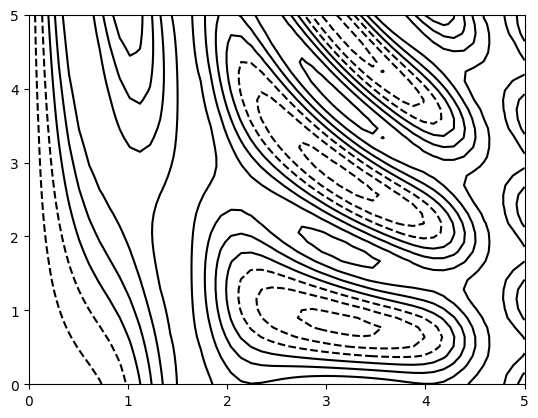

In [ ]:
plt.contour(X, Y, Z, colors='black');

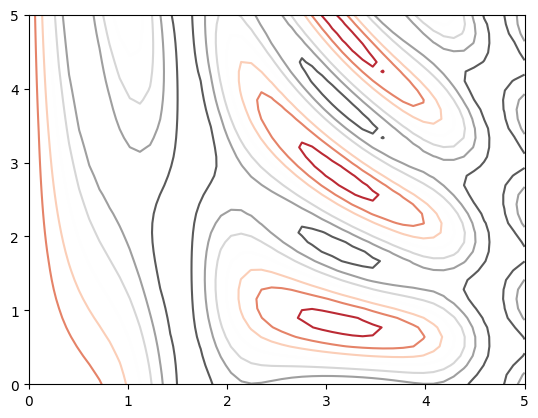

In [ ]:
plt.contour(X, Y, Z, cmap='RdGy');

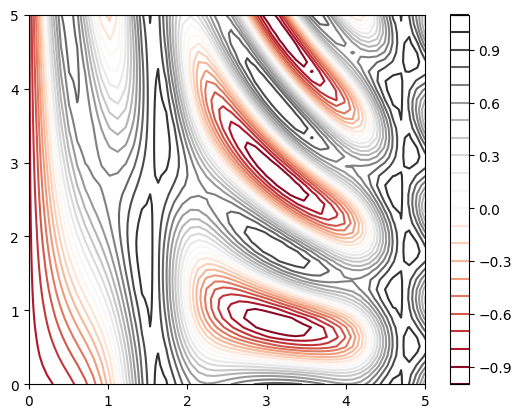

In [ ]:
plt.contour(X, Y, Z, 20, cmap='RdGy');
plt.colorbar();

Answer Following Questions :
1. Explain what changes you observe in the contour plots in the 3 code cells

1)First Plot

plt.contour(X, Y, Z, colors='black')

* Shows only contour lines in black color.

* No color shading is used.

* It simply represents different levels of Z values using lines.

2)Second Plot

plt.contour(X, Y, Z, cmap='RdGy')

* Uses a colormap (RdGy) instead of a single color.

* Different contour levels are represented using different colors.

* Makes the variation in Z values easier to visualize.

3)Third Plot

 plt.contour(X, Y, Z, 20, cmap='RdGy')
plt.colorbar()

* Specifies 20 contour levels, so the plot becomes more detailed.

* The colorbar is added, which shows the mapping between colors and Z values.

* Helps in better interpretation of the data values.

**2. What is the size of X, Y, and Z respectively?**

Given:

x = np.linspace(0,5,50)

y = np.linspace(0,5,40)

* x has 50 values

* y has 40 values

Using:

X, Y = np.meshgrid(x, y)

So the sizes are:

* X : (40 × 50)

* Y : (40 × 50)

* Z : (40 × 50) (because Z = f(X,Y))

**3. How does colorbar() method help in a contour plot?**

* colorbar() adds a color scale beside the plot.

* It shows the relationship between colors and numerical values of Z.

* Helps the user interpret which color corresponds to high or low values.

* Makes the contour plot more informative and easier to analyze.

## Creating Smoother Contour Plots
One potential issue with this plot is that it is a bit "splotchy." That is, the color steps are discrete rather than continuous, which is not always what is desired.

This could be remedied by setting the number of contours to a very high number, but this results in a rather inefficient plot: Matplotlib must render a new polygon for each step in the level. A better way to handle this is to use the plt.imshow() function, which interprets a two-dimensional grid of data as an image.

The following code shows how to perform this:

TypeError: axis() got an unexpected keyword argument 'aspect'

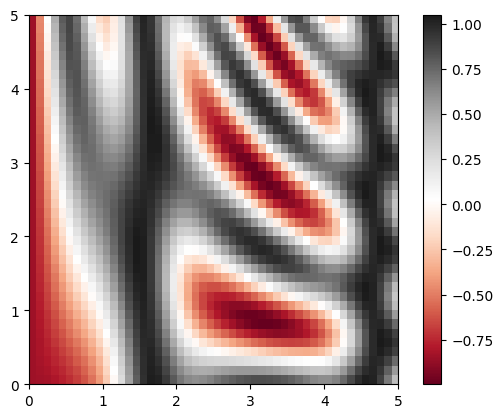

In [ ]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()
plt.axis(aspect='image');

Things to remember while using imshow():

* plt.imshow() doesn't accept an x and y grid, so you must manually specify the
extent [xmin, xmax, ymin, ymax] of the image on the plot.
* plt.imshow() by default follows the standard image array definition where the origin is in the upper left, not in the lower left as in most contour plots. This must be changed when showing gridded data.
* plt.imshow() will automatically adjust the axis aspect ratio to match the input data; this can be changed by setting, for example, plt.axis(aspect='image') to make x and y units match.

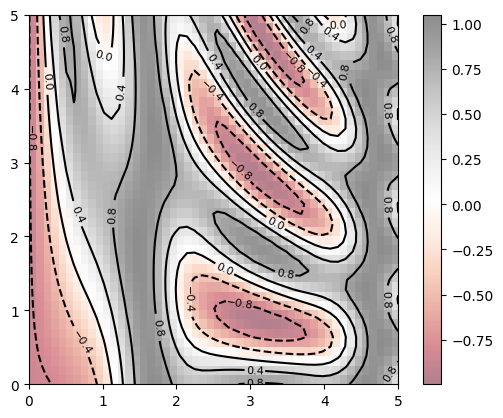

In [ ]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

**1. What does the alpha parameter do?**

In Matplotlib, the alpha parameter controls the transparency (opacity) of a plot element.

* alpha = 0 → Completely transparent (invisible)

* alpha = 1 → Completely opaque (fully visible)

* alpha = 0.5 → Semi-transparent

In the given code:

plt.imshow(Z, extent=[0,5,0,5], origin='lower', cmap='RdGy', alpha=0.5)

* The heatmap image becomes semi-transparent.

* This allows the contour lines drawn on top to be visible clearly.

**2. What does the clabel() method do?**

The clabel() method is used to add labels to contour lines.

Example:

plt.clabel(contours, inline=True, fontsize=8)

Purpose:

* Displays numeric values of contour levels directly on the contour lines.

* Helps the user identify the value represented by each contour line.

* inline=True → Places labels within the contour line.

* fontsize=8 → Sets the size of the label text.

**3. Recreate code with contour levels changed**

Modified Code:

(np.float64(0.0), np.float64(5.0), np.float64(0.0), np.float64(5.0))

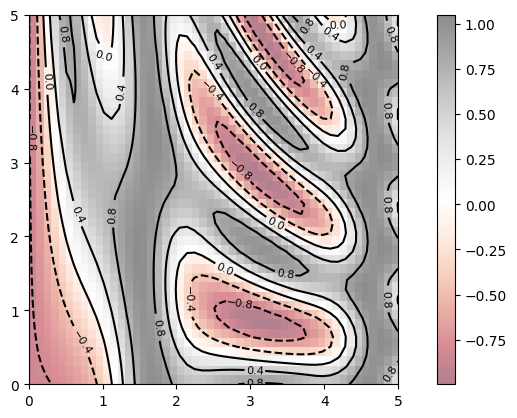

In [ ]:
import matplotlib.pyplot as plt

contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0,5,0,5], origin='lower',
           cmap='RdGy', alpha=0.5)

plt.colorbar()
plt.axis('image')

**Change observed in the plot:**

Increasing contour levels from 3 → 5 creates more contour lines.

The plot becomes more detailed.

The variation of Z values is represented more clearly.

More contour labels appear, giving better understanding of data gradients.

## **Histogram, Binning Plots**
A histogram is a graphical representation of a grouped frequency distribution with continuous classes. It is an area diagram and can be defined as a set of rectangles with bases along with the intervals between class boundaries and with areas proportional to frequencies in the corresponding classes. In such representations, all the rectangles are adjacent since the base covers the intervals between class boundaries. The heights of rectangles are proportional to corresponding frequencies of similar classes and for different classes, the heights will be proportional to corresponding frequency densities.

In other words, a histogram is a diagram involving rectangles whose area is proportional to the frequency of a variable and width is equal to the class interval.

The histogram graph is used under certain conditions. They are:
* The data should be numerical.
* A histogram is used to check the shape of the data distribution.
* Used to check whether the process changes from one period to another.
* used to determine whether the output is different when it involves two or more processes.
* Used to analyse whether the given process meets the customer requirements.

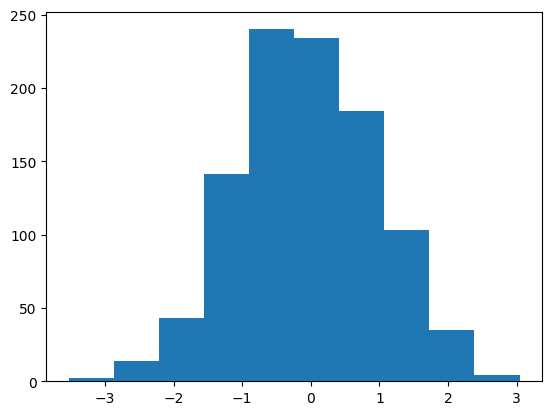

In [ ]:
# How to plot histogram
data = np.random.randn(1000)
plt.hist(data);

The hist() function has many options to tune both the calculation and the display; here's an example of a more customized histogram:

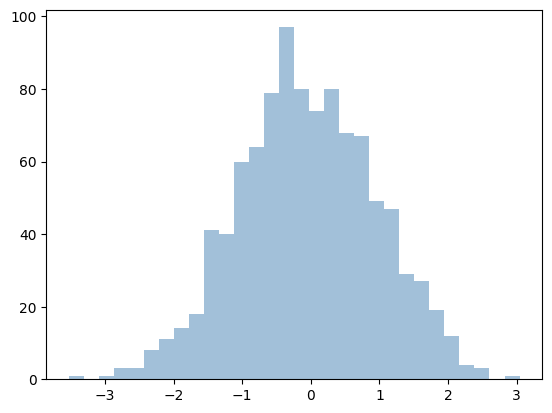

In [ ]:
plt.hist(data, bins=30, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='none');

The plt.hist docstring has more information on other customization options available. I find this combination of histtype='stepfilled' along with some transparency alpha to be very useful when comparing histograms of several distributions:

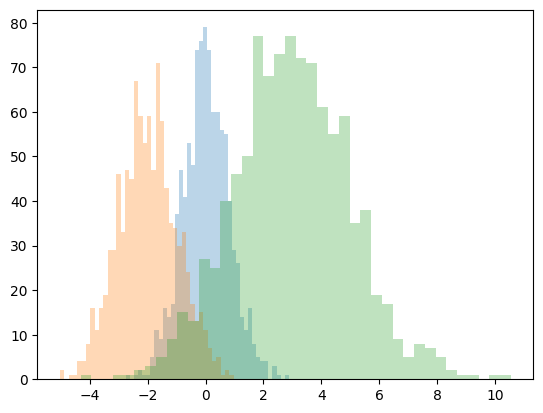

In [ ]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the np.histogram() function is available:

In [ ]:
counts, bin_edges = np.histogram(data, bins=5)
print(counts,bin_edges)

[ 16 184 474 287  39] [-3.53132271 -2.21641629 -0.90150986  0.41339656  1.72830299  3.04320942]


## plt.hist2d: Two-dimensional histogram
One straightforward way to plot a two-dimensional histogram is to use Matplotlib's plt.hist2d function:

In [ ]:
# Create 2 Variable normally distributed data sets with 10000
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

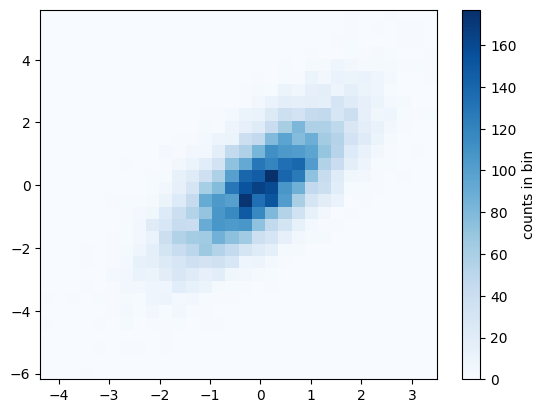

In [ ]:
#Using 2d Histogram plot
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')

Just as with plt.hist, plt.hist2d has a number of extra options to fine-tune the plot and the binning, which are nicely outlined in the function docstring. Further, just as plt.hist has a counterpart in np.histogram, plt.hist2d has a counterpart in np.histogram2d, which can be used as follows:



In [ ]:
counts, xedges, yedges = np.histogram2d(x, y, bins=30)

## plt.hexbin: Hexagonal binnings
The two-dimensional histogram creates a tesselation of squares across the axes. Another natural shape for such a tesselation is the regular hexagon. For this purpose, Matplotlib provides the plt.hexbin routine, which will represents a two-dimensional dataset binned within a grid of hexagons:

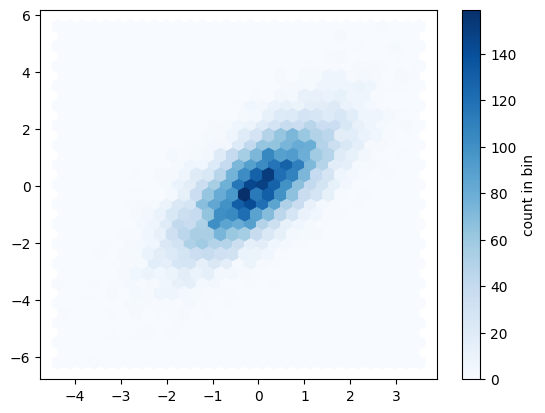

In [ ]:
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

Questions:
1. What is the role of the bins parameter in a histogram plot?

In Matplotlib, the bins parameter determines the number of intervals (groups) into which the data is divided.

Role of bins:

* Divides the dataset into equal-width intervals.

* Counts how many data points fall into each interval.

* Controls the level of detail in the histogram.

Effect of bin size:

* Small number of bins → less detail, smoother graph.

* Large number of bins → more detail, but may look noisy.

Example:

(array([ 1.,  0.,  1.,  3.,  3.,  8., 11., 14., 18., 41., 40., 60., 64.,
        79., 97., 80., 74., 80., 68., 67., 49., 47., 29., 27., 19., 12.,
         4.,  3.,  0.,  1.]),
 array([-3.53132271, -3.31217164, -3.09302057, -2.8738695 , -2.65471843,
        -2.43556736, -2.21641629, -1.99726522, -1.77811415, -1.55896307,
        -1.339812  , -1.12066093, -0.90150986, -0.68235879, -0.46320772,
        -0.24405665, -0.02490558,  0.19424549,  0.41339656,  0.63254764,
         0.85169871,  1.07084978,  1.29000085,  1.50915192,  1.72830299,
         1.94745406,  2.16660513,  2.3857562 ,  2.60490728,  2.82405835,
         3.04320942]),
 <BarContainer object of 30 artists>)

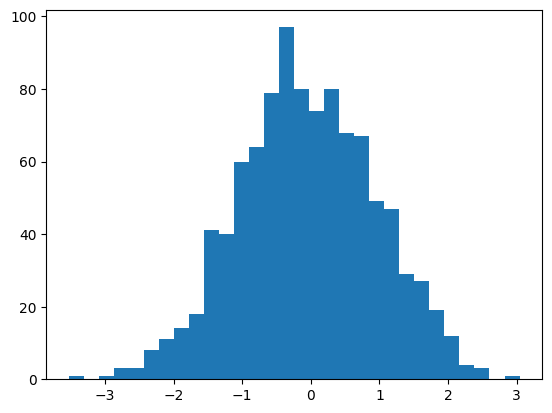

In [ ]:
plt.hist(data, bins=30)

2. Create 10000 uniform random samples and plot histograms

Using NumPy and Matplotlib:

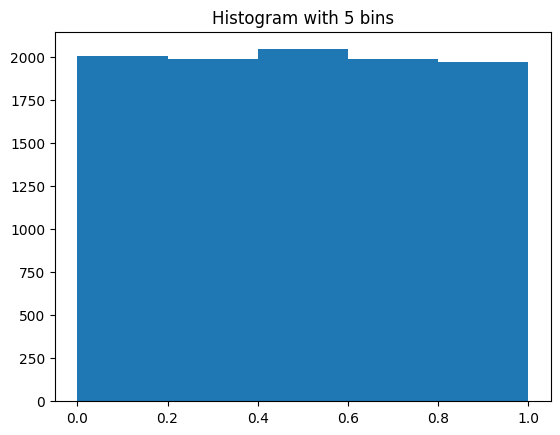

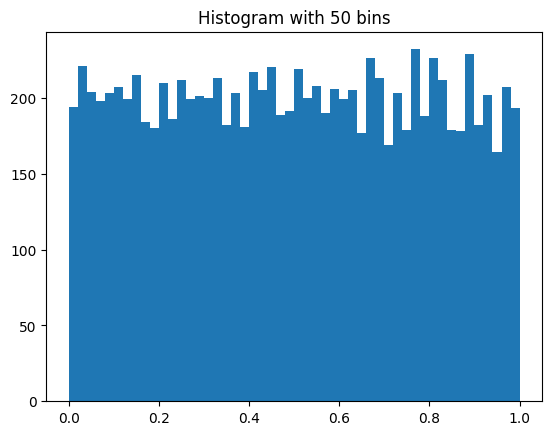

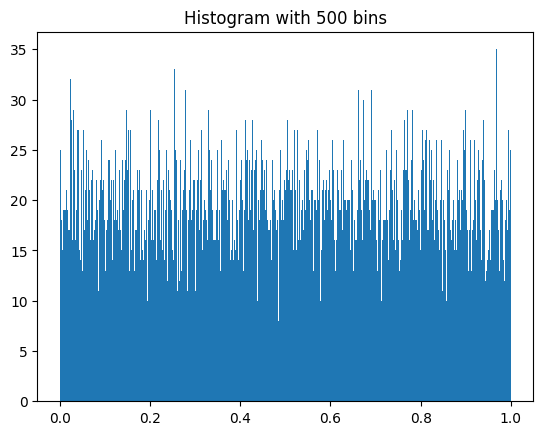

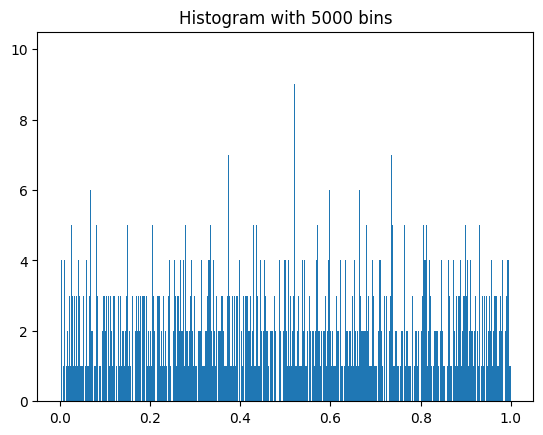

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 10000 uniform random values
norm_data = np.random.rand(10000)

# Histogram with 5 bins
plt.hist(norm_data, bins=5)
plt.title("Histogram with 5 bins")
plt.show()

# Histogram with 50 bins
plt.hist(norm_data, bins=50)
plt.title("Histogram with 50 bins")
plt.show()

# Histogram with 500 bins
plt.hist(norm_data, bins=500)
plt.title("Histogram with 500 bins")
plt.show()

# Histogram with 5000 bins
plt.hist(norm_data, bins=5000)
plt.title("Histogram with 5000 bins")
plt.show()

3. Observations

Bins = 5

* Very broad intervals.

* Histogram appears smooth but less detailed.

Bins = 50

* Shows better distribution pattern.

* Still relatively smooth and easy to interpret.

Bins = 500

* Graph becomes very detailed.

* Individual fluctuations in the data start appearing.

Bins = 5000

* Histogram becomes very noisy and fragmented.

* Hard to interpret because bins are too narrow.

 Conclusion:

The number of bins strongly affects the visualization. A moderate number of bins (like 30–50) usually provides the best balance between detail and readability.

## Ploting from a CSV File

In [ ]:
import pandas as pd
# The drive was already mounted and the 'cities' DataFrame appears to be loaded.
# Removed drive.mount() and pd.read_csv() to use the existing DataFrame.
# cities = pd.read_csv('/content/drive/MyDrive/colab_notebooks/california_cities.csv')

# Extract the data we're interested in using available column names
lat, lon = cities['latitude'], cities['longitude']
population_data = cities['population']

# Scatter the points, using size and color based on population
plt.scatter(lon, lat, label=None,
            c=np.log10(population_data), cmap='viridis',
            s=population_data / 100, linewidth=0, alpha=0.5) # Scaled for better visualization
plt.axis('equal')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.colorbar(label='log (population)')
plt.clim(3, 7)

# Here we create a legend based on population sizes
for pop_size in [1000, 5000, 10000]: # Example population sizes for legend
    plt.scatter([], [], c='k', alpha=0.3, s=pop_size / 100,
                label=f'{pop_size} pop')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title='Population Scale')

plt.title('California Cities: Population and Location');

NameError: name 'cities' is not defined

### Multiple Subplots
Sometimes it is helpful to compare different views of data side by side. Matplotlib has the concept of subplots : groups of smaller axes that can exist together within a single figure.

These subplots might be insets, grids of plots, or other more complicated layouts.



In [ ]:
import numpy as np

### plt.axes: Subplots by Hand (Coding)
The most basic method of creating an axes is to use the plt.axes function. By default this creates a standard axes object that fills the entire figure.

plt.axes also takes an optional argument that is a list of four numbers in the figure coordinate system. These numbers represent [left, bottom, width, height] in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

For example, we might create an inset axes at the top-right corner of another axes by setting the x and y position to 0.65 (that is, starting at 65% of the width and 65% of the height of the figure) and the x and y extents to 0.2 (that is, the size of the axes is 20% of the width and 20% of the height of the figure):



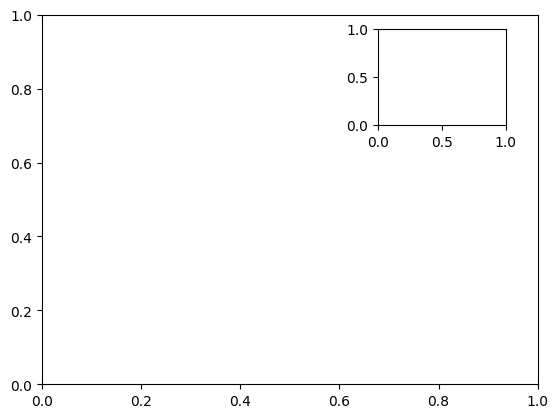

In [ ]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.650, 0.650, 0.2, 0.2]) #inset axes

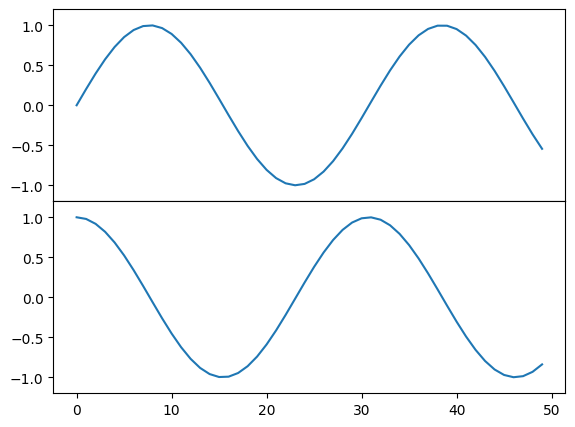

In [ ]:
#creating subplot using fig.add_axes
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2))
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));

### plt.subplot: Simple Grids of Subplots
Aligned columns or rows of subplots are a common-enough need that Matplotlib has several convenience routines that make them easy to create.

The lowest level of these is plt.subplot(), which creates a single subplot within a grid.

As you can see, this command takes three integer arguments—the number of rows, the number of columns, and the index of the plot to be created in this scheme, which runs from the upper left to the bottom right:



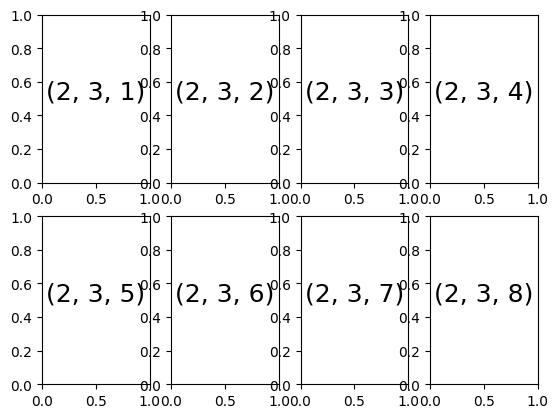

In [ ]:
for i in range(1, 9):
    plt.subplot(2, 4, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=18, ha='center')

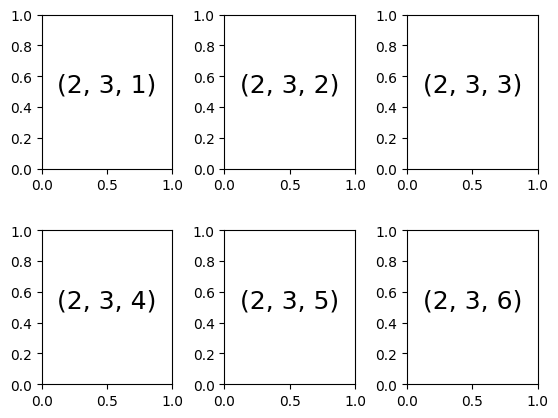

In [ ]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')


### plt.subplots: The Whole Grid in One Go
The approach just described can become quite tedious when creating a large grid of subplots, especially if you'd like to hide the x- and y-axis labels on the inner plots. For this purpose, plt.subplots() is the easier tool to use (note the s at the end of subplots). Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array. The arguments are the number of rows and number of columns, along with optional keywords sharex and sharey, which allow you to specify the relationships between different axes.

Here we'll create a 2*3 grid of subplots, where all axes in the same row share their y-axis scale, and all axes in the same column share their x-axis scale:



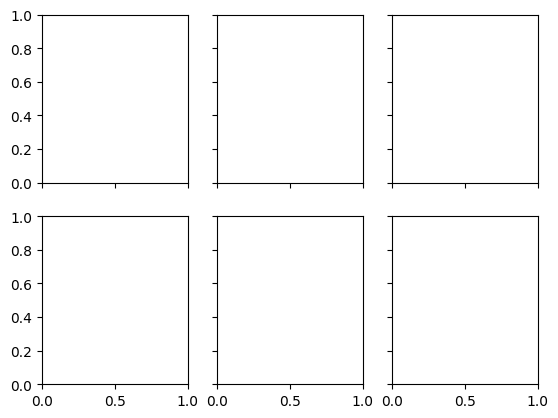

In [ ]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Note that by specifying sharex and sharey, we've automatically removed inner labels on the grid to make the plot cleaner.

The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation:

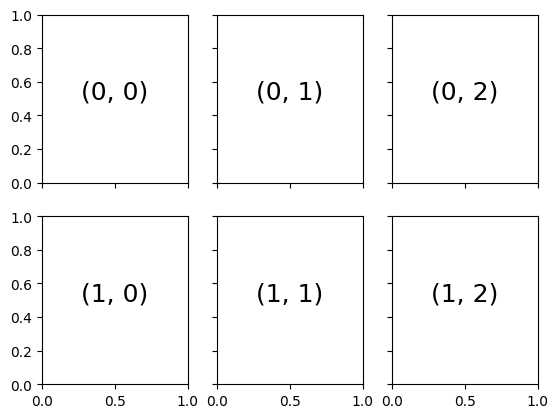

In [ ]:
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=18, ha='center')
fig

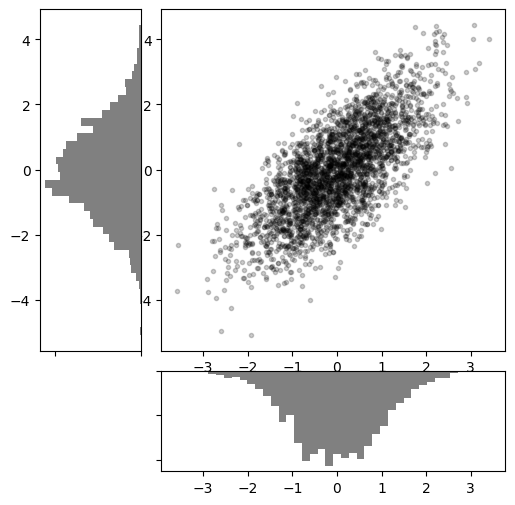

In [ ]:
# An example of Flexible grid arrangement
# Create some normally distributed data
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# Set up the axes with gridspec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# scatter points on the main axes
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2)

# histogram on the attached axes
x_hist.hist(x, 40, histtype='stepfilled',
            orientation='vertical', color='gray')
x_hist.invert_yaxis()

y_hist.hist(y, 40, histtype='stepfilled',
            orientation='horizontal', color='gray')
y_hist.invert_xaxis()


In [ ]:
import matplotlib as mpl
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
# An example of Complex Plotting
births = pd.read_csv('/content/drive/MyDrive/colab_notebook/births.csv')

quartiles = np.percentile(births['births'], [25, 50, 75])
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

births['day'] = births['day'].astype(int)

births.index = pd.to_datetime(10000 * births.year +
                              100 * births.month +
                              births.day, format='%Y%m%d')
births_by_date = births.pivot_table('births',
                                    [births.index.month, births.index.day])
births_by_date.index = [pd.Timestamp(2012, month, day)
                        for (month, day) in births_by_date.index]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/colab_notebook/births.csv'

NameError: name 'births_by_date' is not defined

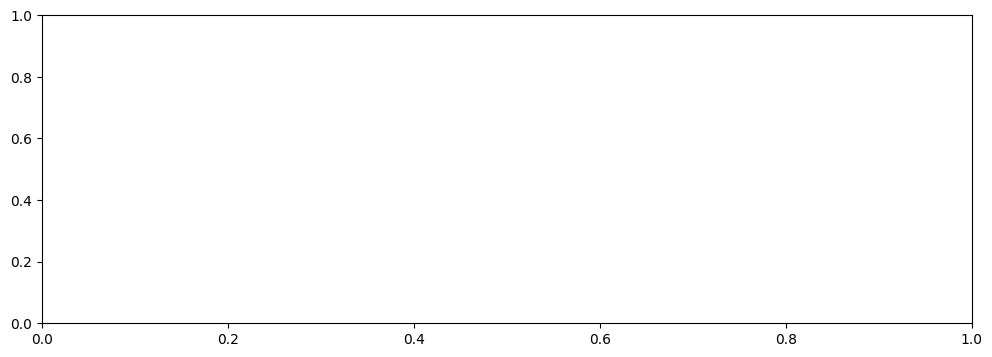

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax);

### **Boxplot**
A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum.

In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.

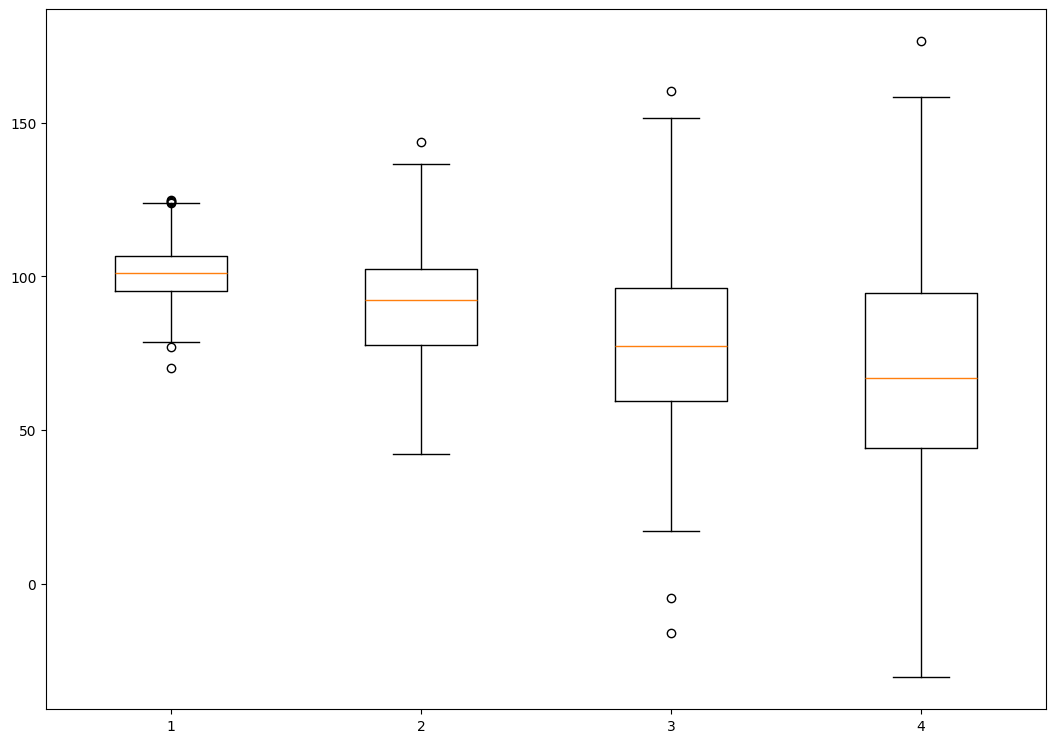

In [ ]:
#Exmple of Box plot for some random data sets
# Import libraries
import matplotlib.pyplot as plt
import numpy as np


# Creating dataset
np.random.seed(10)

data_1 = np.random.normal(100, 10, 200)
data_2 = np.random.normal(90, 20, 200)
data_3 = np.random.normal(80, 30, 200)
data_4 = np.random.normal(70, 40, 200)
data = [data_1, data_2, data_3, data_4]

fig = plt.figure(figsize =(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data)

# show plot
plt.show()

**Questions:**

Q1. What is boxplot ?

A Box Plot, also known as a Whisker plot, is a graphical representation used to display the summary of a set of data values. It highlights properties such as the minimum, first quartile, median, third quartile, and maximum values.

In a box plot:
*  A box is drawn from the first quartile to the third quartile.
* A vertical line goes through the box at the median.
* The x-axis usually denotes the data to be plotted, while the y-axis shows the frequency distribution.

Q2.What information do we get from a box plot?

From a box plot, you can obtain several key pieces of information about a dataset:

  * Minimum Value: The lowest data point within the 1.5 IQR
(interquartile range) of the lower quartile.
  * First Quartile (Q1): Represents the 25th percentile of the data, meaning 25% of the data falls below this value.
  * Median (Q2): This is the middle value of the dataset, representing the 50th percentile. It divides the data into two equal halves.
  * Third Quartile (Q3): Represents the 75th percentile of the data, meaning 75% of the data falls below this value.
  * Maximum Value: The highest data point within the 1.5 IQR of the upper quartile.
    * Interquartile Range (IQR): The range between the first and third quartiles (Q3 - Q1), which covers the middle 50% of the data.
  * Outliers: Data points that fall outside the typical range (beyond the whiskers) are often plotted individually, indicating potential outliers.



Q3. How is minimum and maximum whisker's marked in a box plot ?

In a box plot, the whiskers typically extend from the edges of the box (the first and third quartiles) to the most extreme data points that are not considered outliers. The length of the whiskers is usually determined as follows:

* Upper Whisker: Extends from the third quartile (Q3) to the highest data point within 1.5 times the Interquartile Range (IQR) above Q3. Any data points beyond this are considered outliers and are plotted individually.
* Lower Whisker: Extends from the first quartile (Q1) to the lowest data point within 1.5 times the Interquartile Range (IQR) below Q1. Any data points beyond this are considered outliers and are plotted individually.

The Interquartile Range (IQR) is the difference between the third quartile (Q3) and the first quartile (Q1), i.e., IQR = Q3 - Q1.

Q4. How to we identify that some points in data are outliers by viewing the box plot?

In a box plot, data points that are considered outliers are typically plotted individually as single points beyond the whiskers.

As previously mentioned, the whiskers extend to the most extreme data points that are within 1.5 times the Interquartile Range (IQR) from the first (Q1) and third (Q3) quartiles. Any data points that fall outside this range (i.e., further than 1.5 * IQR below Q1 or above Q3) are marked as individual points (often circles, crosses, or other distinct markers) indicating they are outliers.



Q5. Read a data file from your drive and for all numeric columns plot boxplot.

In [ ]:
data_file_path = input("Enter the full path to your data file: ")
print(f"Data file path set to: {data_file_path}")

Enter the full path to your data file: '/content/drive/MyDrive/colab_notebook/births.csv'
Data file path set to: '/content/drive/MyDrive/colab_notebook/births.csv'


In [ ]:
import pandas as pd

# Correct the data_file_path to include the full Google Drive path
if not data_file_path.startswith('/content/drive'):
    data_file_path = f'/content/drive/{data_file_path}'

# Load the data into a pandas DataFrame
df = pd.read_csv(data_file_path)

print(f"Successfully loaded data from: {data_file_path}")
print("First 5 rows of the DataFrame:")
df.head()

Successfully loaded data from: /content/drive/MyDrive/colab_notebook/california_cities.csv
First 5 rows of the DataFrame:


,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns
print("Numeric columns identified:")
print(numeric_cols.tolist())

Numeric columns identified:
['Unnamed: 0', 'latd', 'longd', 'elevation_m', 'elevation_ft', 'population_total', 'area_total_sq_mi', 'area_land_sq_mi', 'area_water_sq_mi', 'area_total_km2', 'area_land_km2', 'area_water_km2', 'area_water_percent']


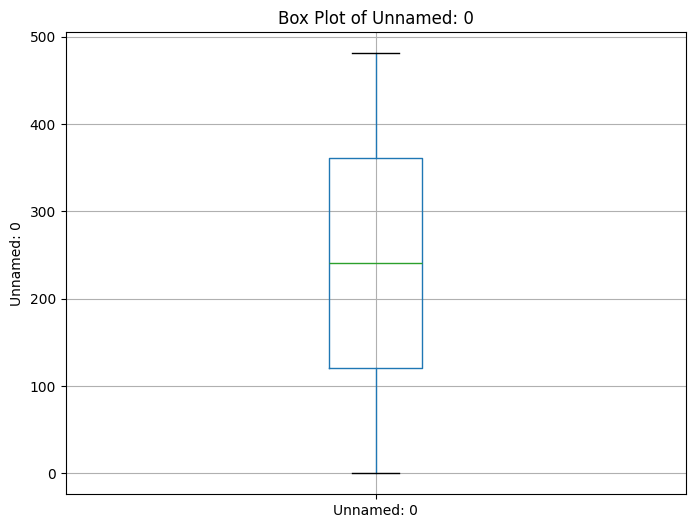

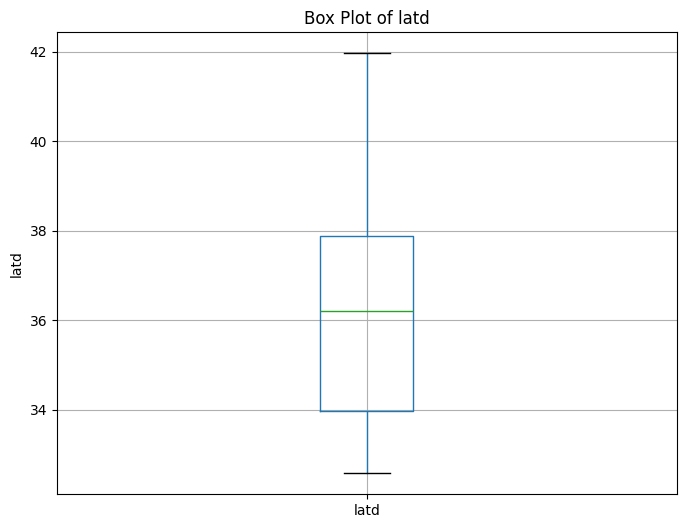

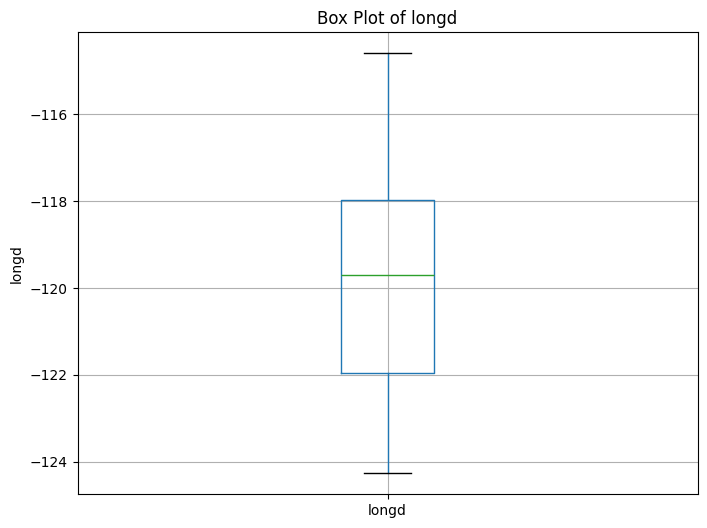

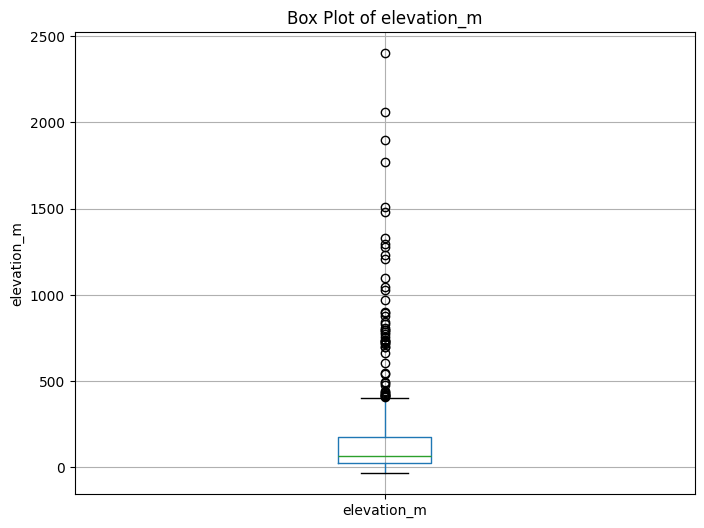

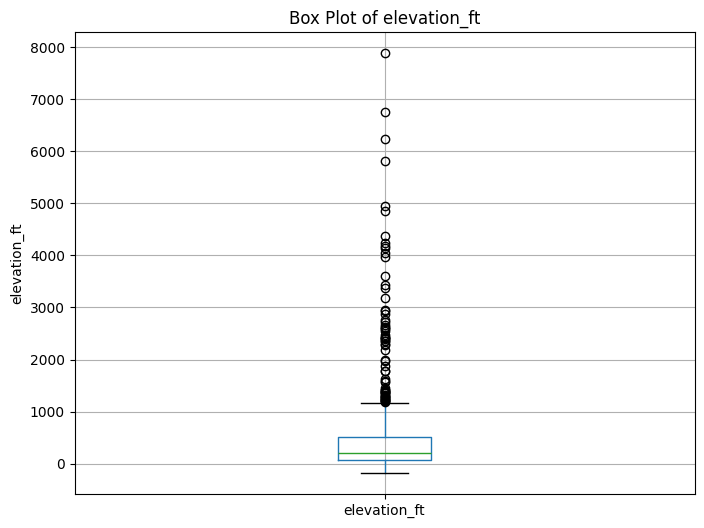

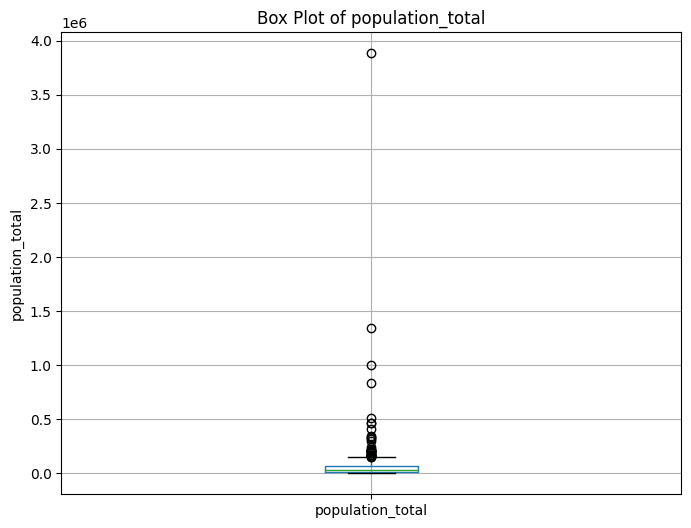

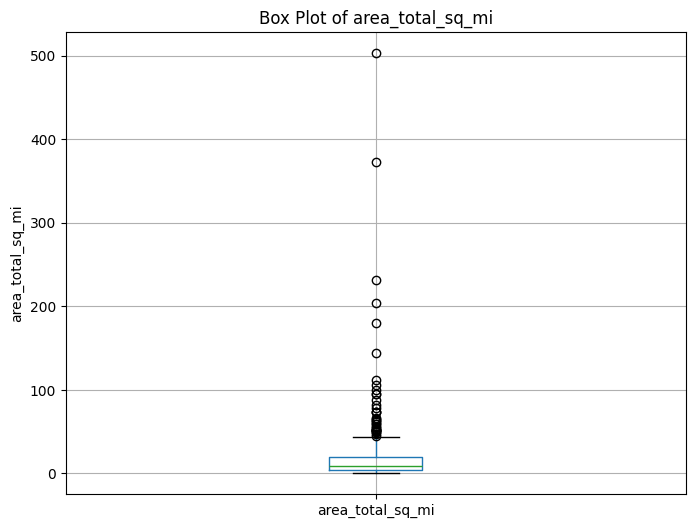

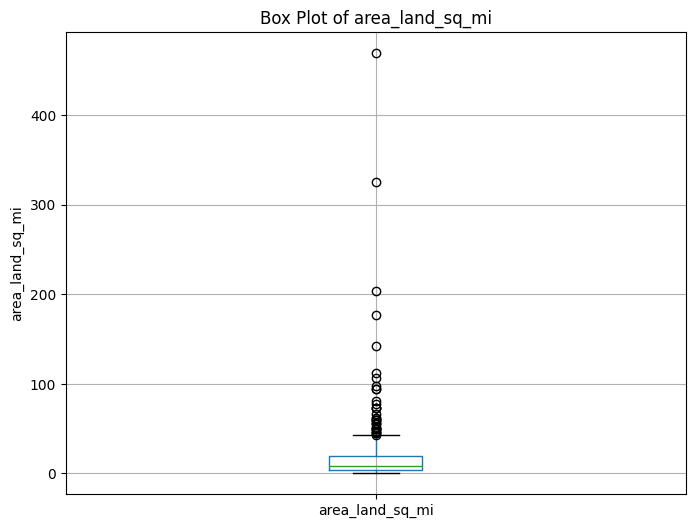

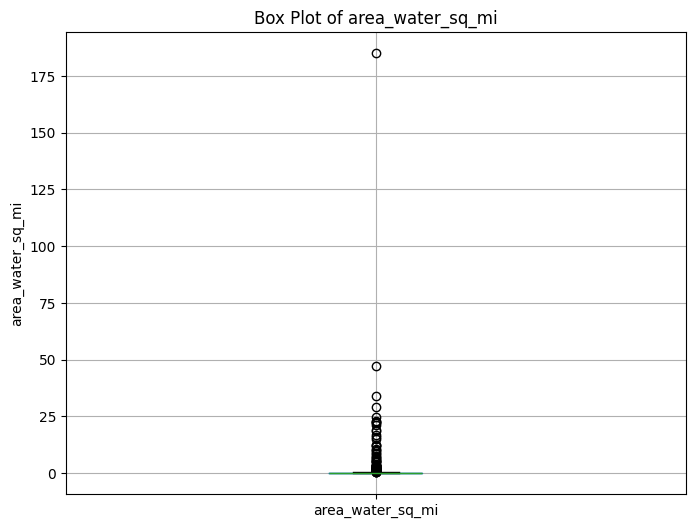

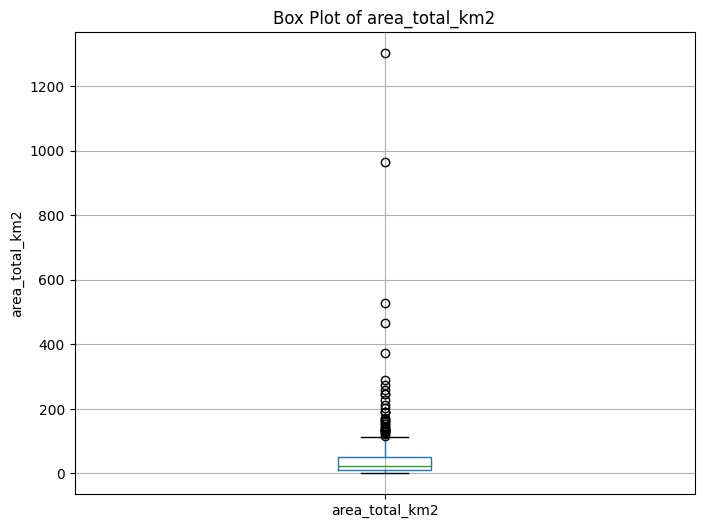

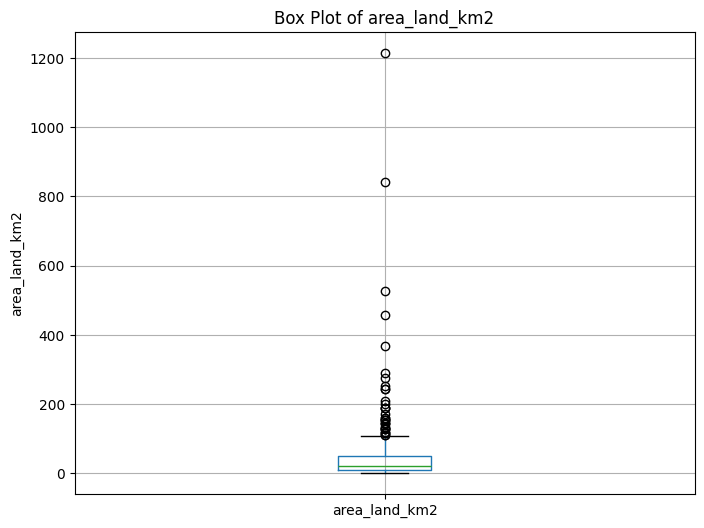

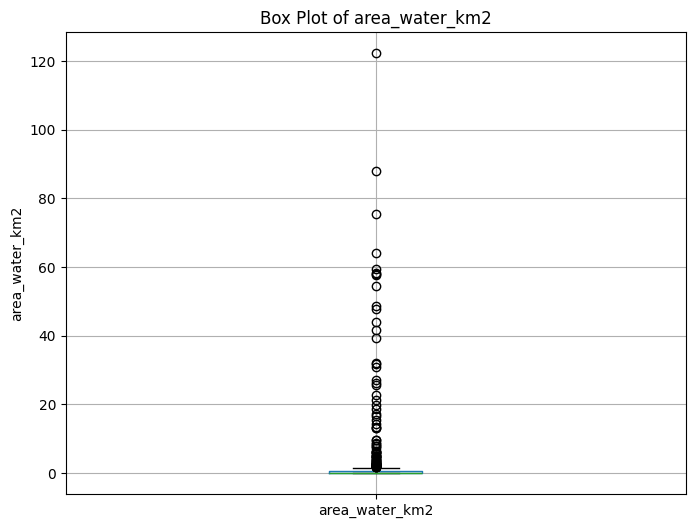

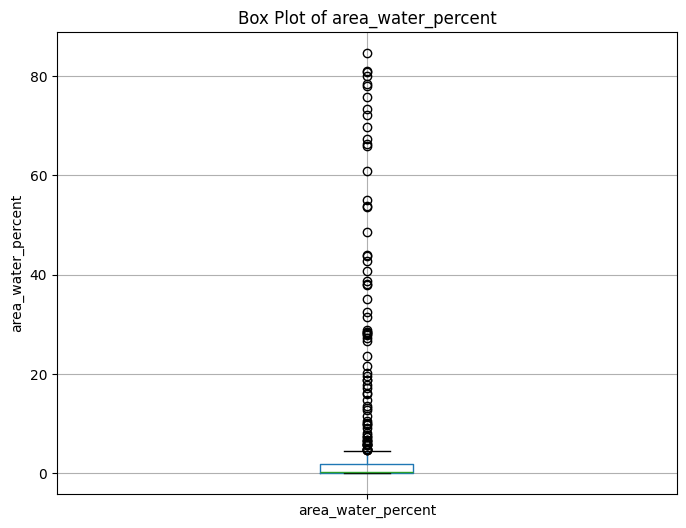

In [ ]:
import matplotlib.pyplot as plt

# Create box plots for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    df.boxplot(column=col)
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

## **Conclusion**

Thus we have learned about basics of Contour plots, Histograms, Box plots.
